In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def analyze_null_values(df, target_col=None, threshold=0.05):
    """
    Comprehensive null value analysis and recommendations
    
    Parameters:
    df : pandas DataFrame
    target_col : str, target variable name (optional)
    threshold : float, materiality threshold for null impact
    
    Returns:
    dict with analysis results and recommendations
    """
    
    def calculate_null_metrics(df):
        """Calculate null metrics for each column"""
        metrics = pd.DataFrame({
            'null_count': df.isnull().sum(),
            'null_pct': df.isnull().mean(),
            'dtype': df.dtypes,
            'unique_values': df.nunique(),
            'unique_pct': df.nunique() / len(df)
        })
        
        # Add null patterns
        metrics['null_pattern'] = metrics.index.map(
            lambda x: identify_null_pattern(df[x])
        )
        
        return metrics
    
    def identify_null_pattern(series):
        """Identify pattern in null values"""
        if series.isnull().sum() == 0:
            return "No nulls"
        
        # Check for time-based patterns
        if hasattr(series.index, 'month'):
            monthly_nulls = series.isnull().groupby(series.index.month).mean()
            if monthly_nulls.std() > 0.1:
                return "Seasonal pattern"
                
        # Check for value-based patterns
        if series.dtype in ['int64', 'float64']:
            null_indices = series.isnull()
            if null_indices.any():
                value_before_null = series.shift(1)[null_indices].mean()
                value_after_null = series.shift(-1)[null_indices].mean()
                if abs(value_before_null - value_after_null) > series.std():
                    return "Value-dependent pattern"
        
        return "Random pattern"
    
    def analyze_null_impact(df, col, target_col):
        """Analyze impact of nulls on target variable"""
        if target_col is None:
            return None
            
        # Split data into null and non-null groups
        null_mask = df[col].isnull()
        null_group = df[null_mask][target_col]
        non_null_group = df[~null_mask][target_col]
        
        # Statistical tests
        if len(null_group) > 0 and len(non_null_group) > 0:
            # For numeric target
            if df[target_col].dtype in ['int64', 'float64']:
                stat, pvalue = stats.ttest_ind(
                    null_group,
                    non_null_group,
                    nan_policy='omit'
                )
            # For categorical target
            else:
                contingency = pd.crosstab(
                    df[col].isnull(),
                    df[target_col]
                )
                stat, pvalue = stats.chi2_contingency(contingency)[:2]
                
            return {
                'statistic': stat,
                'pvalue': pvalue,
                'null_target_mean': null_group.mean(),
                'non_null_target_mean': non_null_group.mean()
            }
        return None
    
    def recommend_treatment(metrics_row, impact_analysis):
        """Recommend treatment for null values"""
        null_pct = metrics_row['null_pct']
        dtype = metrics_row['dtype']
        pattern = metrics_row['null_pattern']
        
        if null_pct == 0:
            return "No treatment needed"
            
        recommendations = []
        
        # High null percentage
        if null_pct > 0.5:
            recommendations.append("Consider dropping column")
        
        # Medium null percentage
        elif 0.1 < null_pct <= 0.5:
            if dtype in ['int64', 'float64']:
                if pattern == "Value-dependent pattern":
                    recommendations.append("Use interpolation")
                else:
                    recommendations.append("Use median/mean imputation")
            else:
                recommendations.append("Use mode imputation or create 'Missing' category")
        
        # Low null percentage
        else:
            if dtype in ['int64', 'float64']:
                recommendations.append("Use median imputation")
            else:
                recommendations.append("Use mode imputation")
        
        # Add impact-based recommendations
        if impact_analysis and impact_analysis['pvalue'] < 0.05:
            recommendations.append("Create missing indicator variable")
        
        return " | ".join(recommendations)
    
    # Calculate basic metrics
    metrics = calculate_null_metrics(df)
    
    # Analyze impact on target
    if target_col:
        impact_analysis = {
            col: analyze_null_impact(df, col, target_col)
            for col in df.columns if col != target_col
        }
    else:
        impact_analysis = None
    
    # Add recommendations
    metrics['recommendation'] = metrics.apply(
        lambda row: recommend_treatment(row, 
            impact_analysis.get(row.name) if impact_analysis else None
        ),
        axis=1
    )
    
    # Visualize null patterns
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Null percentage by column
    metrics['null_pct'].sort_values().plot(
        kind='barh',
        ax=axes[0,0],
        title='Null Percentage by Column'
    )
    
    # Null correlation heatmap
    null_corr = df.isnull().corr()
    sns.heatmap(
        null_corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        ax=axes[0,1]
    )
    axes[0,1].set_title('Null Correlation Matrix')
    
    # Null patterns over time if datetime index
    if isinstance(df.index, pd.DatetimeIndex):
        df.isnull().sum(axis=1).plot(
            ax=axes[1,0],
            title='Null Counts Over Time'
        )
    
    # Impact on target if provided
    if target_col and impact_analysis:
        impact_df = pd.DataFrame({
            col: [analysis['null_target_mean'] if analysis else np.nan,
                 analysis['non_null_target_mean'] if analysis else np.nan]
            for col, analysis in impact_analysis.items()
        }, index=['Null', 'Non-Null'])
        
        impact_df.plot(
            kind='bar',
            ax=axes[1,1],
            title=f'Impact on {target_col}'
        )
    
    plt.tight_layout()
    
    return {
        'metrics': metrics,
        'impact_analysis': impact_analysis,
        'visualization': fig,
        'summary': generate_summary(metrics, impact_analysis)
    }

def generate_summary(metrics, impact_analysis):
    """Generate summary of null analysis"""
    high_null_cols = metrics[metrics['null_pct'] > 0.5].index.tolist()
    impactful_cols = []
    
    if impact_analysis:
        impactful_cols = [
            col for col, analysis in impact_analysis.items()
            if analysis and analysis['pvalue'] < 0.05
        ]
    
    summary = [
        "Null Analysis Summary:",
        f"- Total columns with nulls: {(metrics['null_pct'] > 0).sum()}",
        f"- Columns with >50% nulls: {len(high_null_cols)}",
        f"- Columns with significant impact on target: {len(impactful_cols)}",
        "\nRecommended Actions:",
        "1. Consider dropping: " + ", ".join(high_null_cols),
        "2. Create missing indicators for: " + ", ".join(impactful_cols)
    ]
    
    return "\n".join(summary)

# Example usage:
# analysis = analyze_null_values(df, target_col='default')
# print(analysis['summary'])
# print("\nDetailed Metrics:")
# print(analysis['metrics'])

Null Analysis Summary:
- Total columns with nulls: 3
- Columns with >50% nulls: 0
- Columns with significant impact on target: 0

Recommended Actions:
1. Consider dropping: 
2. Create missing indicators for: 

Detailed Recommendations:
                        null_pct      null_pattern  \
numeric_random_nulls    0.104110    Random pattern   
numeric_seasonal_nulls  0.252055  Seasonal pattern   
categorical             0.361644    Random pattern   
target                  0.000000          No nulls   

                                                          recommendation  
numeric_random_nulls                          Use median/mean imputation  
numeric_seasonal_nulls                        Use median/mean imputation  
categorical             Use mode imputation or create 'Missing' category  
target                                               No treatment needed  


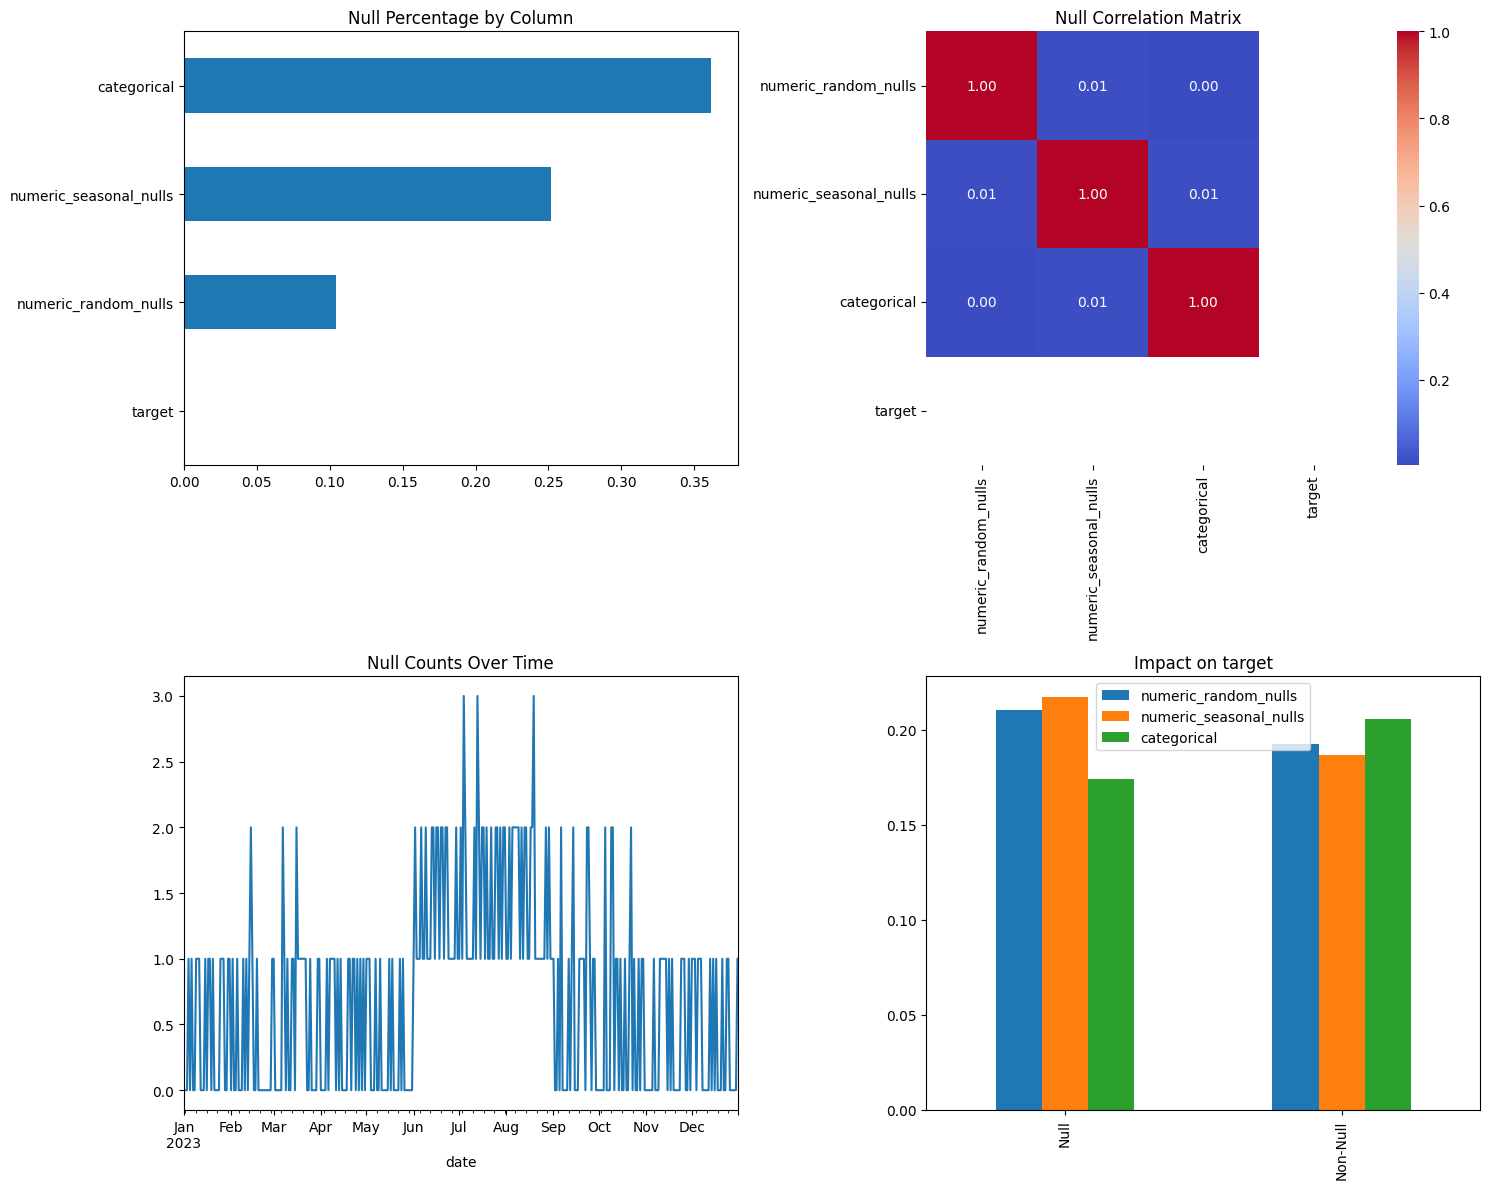

In [3]:
# Create sample dataset with various null patterns
np.random.seed(42)
dates = pd.date_range('2023-01-01', '2023-12-31')
n_samples = len(dates)

df = pd.DataFrame({
    'date': dates,
    'numeric_random_nulls': np.random.normal(0, 1, n_samples),
    'numeric_seasonal_nulls': np.random.normal(0, 1, n_samples),
    'categorical': np.random.choice(['A', 'B', 'C'], n_samples),
    'target': np.random.choice([0, 1], n_samples, p=[0.8, 0.2])
})

# Add different null patterns
df.loc[np.random.choice([True, False], n_samples, p=[0.1, 0.9]), 'numeric_random_nulls'] = np.nan
df.loc[df.date.dt.month.isin([6,7,8]), 'numeric_seasonal_nulls'] = np.nan
df.loc[df.categorical == 'A', 'categorical'] = np.nan

# Set date as index
df.set_index('date', inplace=True)

# Run analysis
analysis = analyze_null_values(df, target_col='target')

# Print results
print(analysis['summary'])
print("\nDetailed Recommendations:")
print(analysis['metrics'][['null_pct', 'null_pattern', 'recommendation']])